# Lecture 05
                                      
## plotnine             
            
- data import and filter
- `ggplot` and `aes` – building blocks of graphs
- themes
- manipulating axis              
- adding lines and annotations                  
- other frequently used other plots:     
    - bar, box, violin
                                    
#### Case study
- Ch03B Comparing hotel prices in Europe: Vienna vs London     
                                      
#### Dataset used
- hotels-europe       
----

Import packages

In [1]:
import pandas as pd
import numpy as np
from plotnine import *
import warnings

%matplotlib inline
warnings.filterwarnings("ignore")

### Data import and filter
Use the london-vienna dataset to introduce different aspects of plotnine


import the prices and features of hotels

In [2]:
import os
import pandas as pd

# Define the subfolder and file paths
work_dir = "workfile"
os.makedirs(work_dir, exist_ok=True)

price_file_path = os.path.join(work_dir, "hotels_europe_price.csv")
features_file_path = os.path.join(work_dir, "hotels_europe_features.csv")

# URLs for the datasets
price_url = "https://osf.io/p6tyr/download"
features_url = "https://osf.io/utwjs/download"

# 1. Handle hotels_europe_price
if os.path.exists(price_file_path):
    print(f"Loading {price_file_path} from local storage...")
    hotels_europe_price = pd.read_csv(price_file_path)
else:
    print(f"Downloading {price_url}...")
    hotels_europe_price = pd.read_csv(price_url)
    # Save to local folder for next time
    hotels_europe_price.to_csv(price_file_path, index=False)
    print(f"Saved {price_file_path}")

# 2. Handle hotels_europe_features
if os.path.exists(features_file_path):
    print(f"Loading {features_file_path} from local storage...")
    hotels_europe_features = pd.read_csv(features_file_path)
else:
    print(f"Downloading {features_url}...")
    hotels_europe_features = pd.read_csv(features_url)
    # Save to local folder for next time
    hotels_europe_features.to_csv(features_file_path, index=False)
    print(f"Saved {features_file_path}")

Loading workfile/hotels_europe_price.csv from local storage...
Loading workfile/hotels_europe_features.csv from local storage...


Join them by hotel_id

In [3]:
df = hotels_europe_price.merge(hotels_europe_features, on = "hotel_id")
df.head()

,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room,...,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
0,1,172,0,0% no offer,2017,11,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
1,1,122,1,15-50% offer,2018,1,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
2,1,122,1,15-50% offer,2017,12,0,1,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
3,1,552,1,1-15% offer,2017,12,0,1,4,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
4,1,122,1,15-50% offer,2018,2,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel


Filter

In [4]:
df = (
    df.loc[(df["year"] == 2017) & (df["month"] == 11) & (df["weekend"] == 0)]
    .loc[
        (df["city"].isin(["Vienna", "London"]))
        & (df["city_actual"].isin(["Vienna", "London"]))
    ]
    .loc[df["accommodation_type"] == "Hotel"]
    .loc[(df["stars"] >= 3) & (df["stars"] <= 4)]
    .loc[df["price"] <= 600]
)

Delete unnecessary input files from memory

In [5]:
del hotels_europe_features
del hotels_europe_price

### Building Blocks of Graphs (`ggplot` and `aes`); Themes

We use the `plotnine` package for visualization in Python. This package relates to the ggplot package in R. 

plotnine always has a `ggplot()` function which we usually supply with the data and axis variables and a `geom_*type*()` function added, which decides the type of the graph we want to plot.

Lets create a basic histogram in plotnine

First, filter on the Vienna hotels

In [9]:
vienna_hotels = df.loc[df["city_actual"] == "Vienna"]
vienna_hotels.head()


,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room,...,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
140450,21897,81,1,1-15% offer,2017,11,0,0,1,0,...,Austria,Vienna,189.0,City centre,Donauturm,17. Hernals,3.5,708.0,3.8,Hotel
140472,21901,85,1,15-50% offer,2017,11,0,0,1,0,...,Austria,Vienna,53.0,City centre,Donauturm,Alsergrund,3.5,629.0,2.5,Hotel
140482,21902,83,1,15-50% offer,2017,11,0,0,1,0,...,Austria,Vienna,55.0,City centre,Donauturm,Alsergrund,4.0,52.0,2.5,Hotel
140492,21903,82,1,15-50% offer,2017,11,0,0,1,1,...,Austria,Vienna,33.0,City centre,Donauturm,Alsergrund,3.5,219.0,2.8,Hotel
140505,21906,103,0,0% no offer,2017,11,0,0,1,1,...,Austria,Vienna,57.0,City centre,Donauturm,Alsergrund,3.5,251.0,2.4,Hotel


Create the ggplot object, with data and specify the x-axis in the `aes()` function

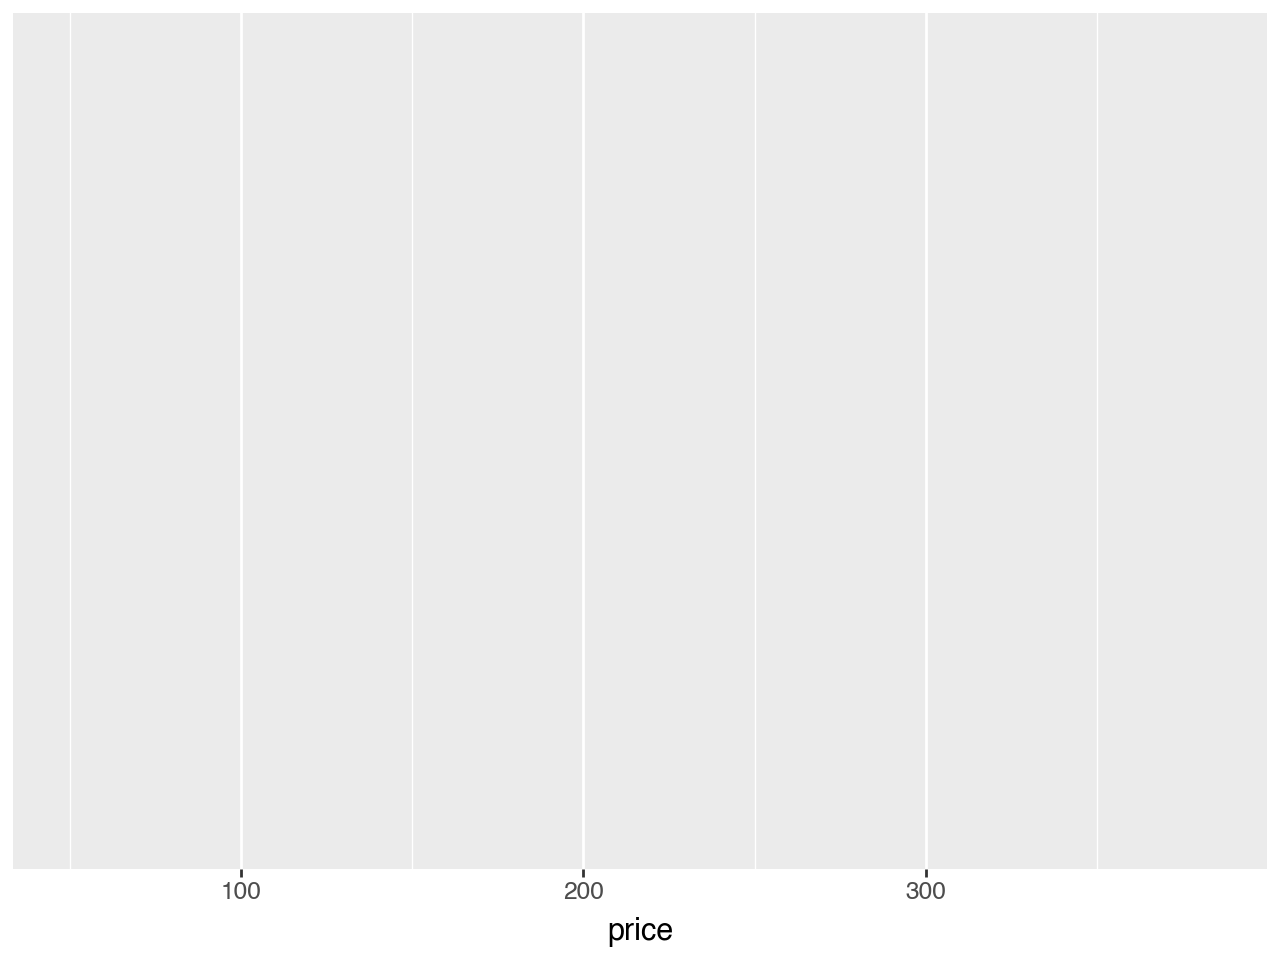

In [7]:
ggplot(vienna_hotels, aes(x="price"))

As you can see, plotnine recognised the range of the `price` variable, however since we did not supply a `geom_*type*()` it cannod decide what kind of plot we would like to see. 

Let's create a histogram, for which the corresponding function is called `geom_histogram()`

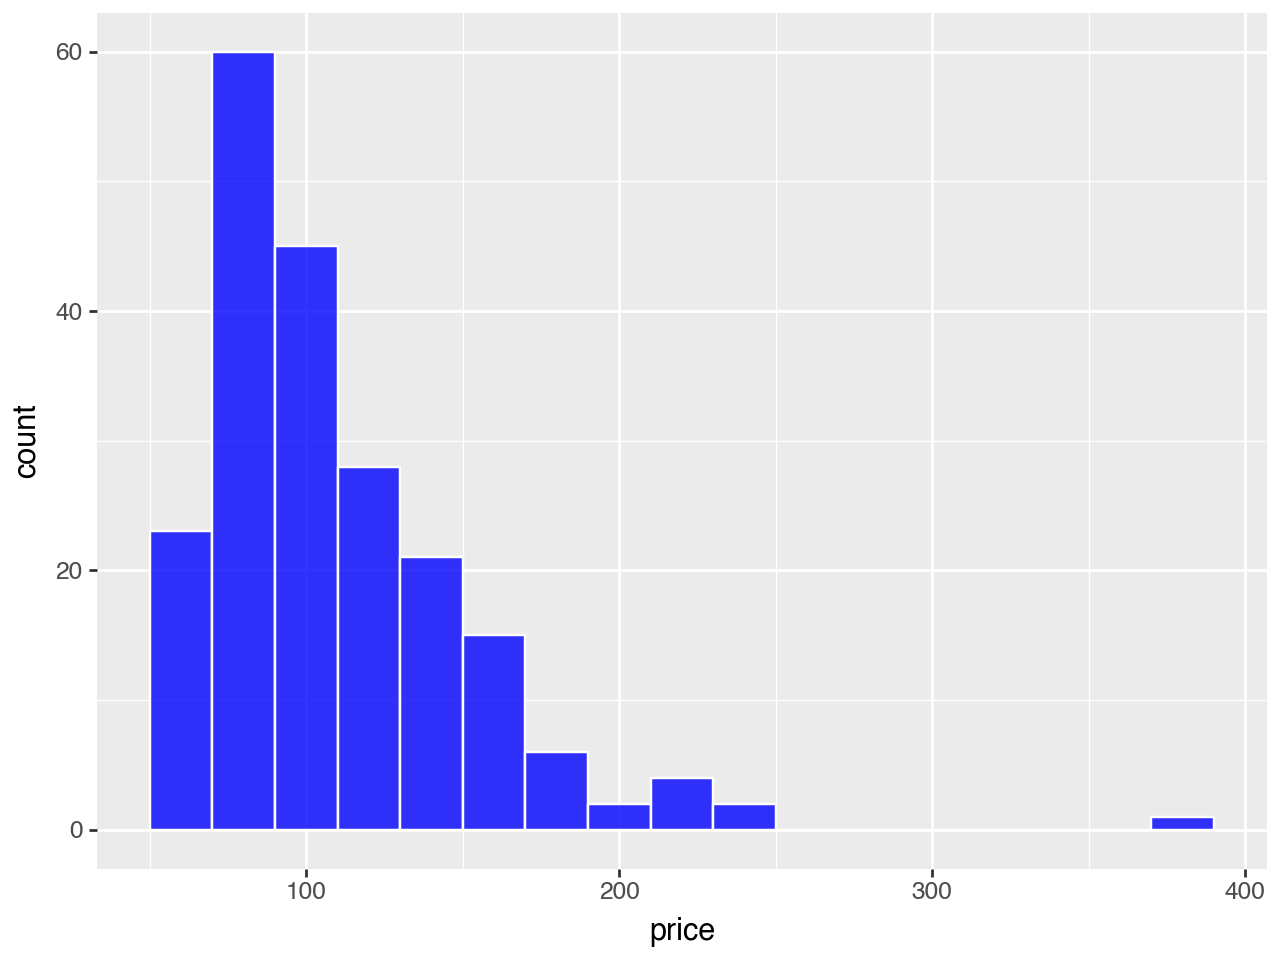

In [17]:
(
    ggplot(vienna_hotels, aes(x="price"))
    + geom_histogram(
        alpha=0.8, # alpha controls the transparency of bars
        binwidth=20, # sets the width of bins (bars)
        color="white", # sets color for the contour of the bars
        fill="blue", # sets color for the fill of the bars
    )
)

Set the title of axises using the `labs` function

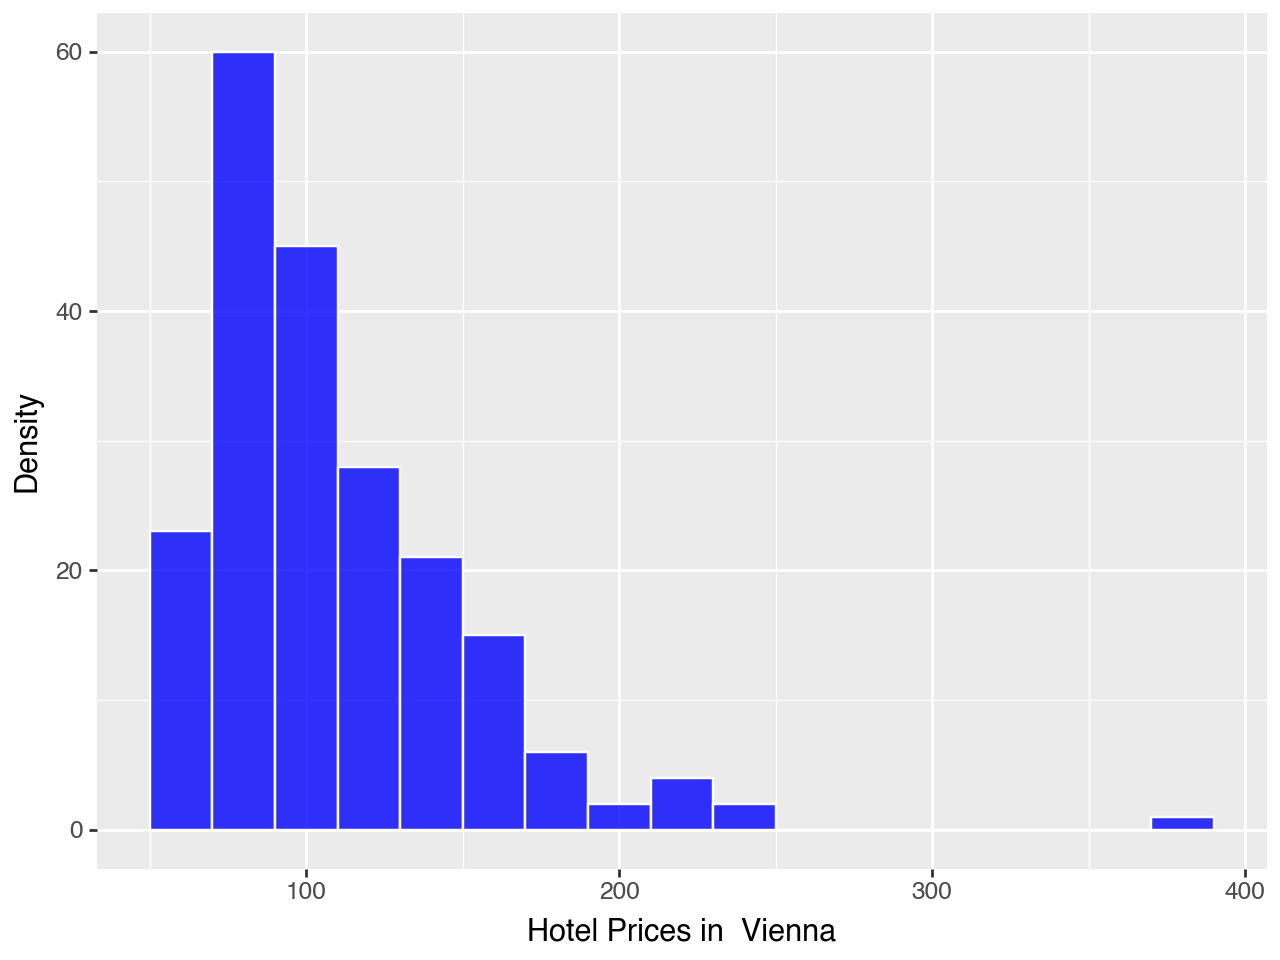

In [18]:
(
    ggplot(vienna_hotels, aes(x="price"))
    + geom_histogram(alpha=0.8, binwidth=20, color="white", fill="blue")
    + labs(x="Hotel Prices in  Vienna", y="Density")
)

You can try different themes in plotnine

 Mostly used: theme_bw(), theme_grey(), theme_gray(), theme_linedraw(), theme_light, theme_dark,            theme_minimal(), theme_classic(), theme_void()

___

theme_bw

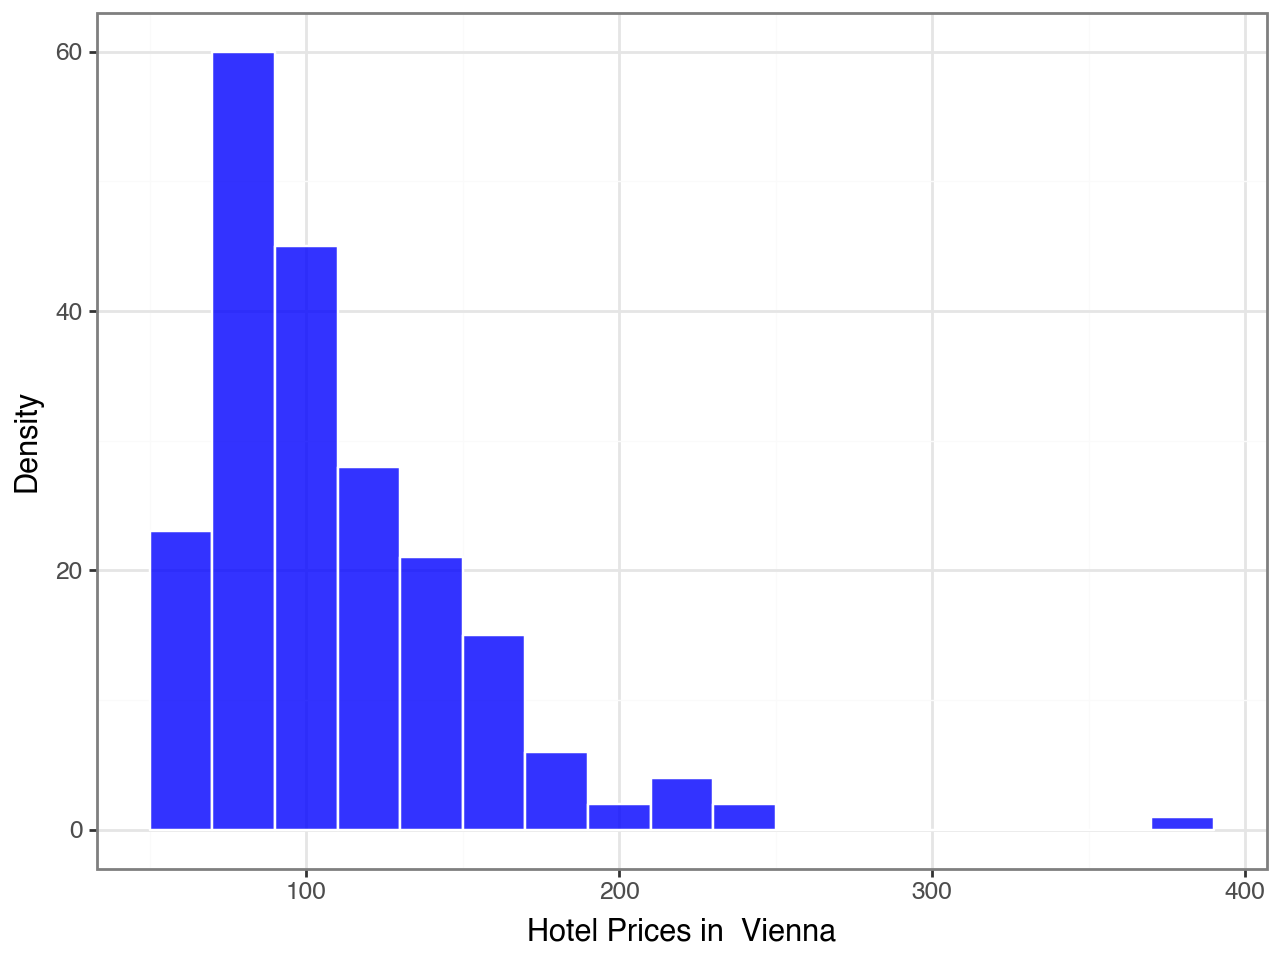

In [19]:
(
    ggplot(vienna_hotels, aes(x="price"))
    + geom_histogram(alpha=0.8, binwidth=20, color="white", fill="blue")
    + labs(x="Hotel Prices in  Vienna", y="Density")
    + theme_bw()
)

theme_classic

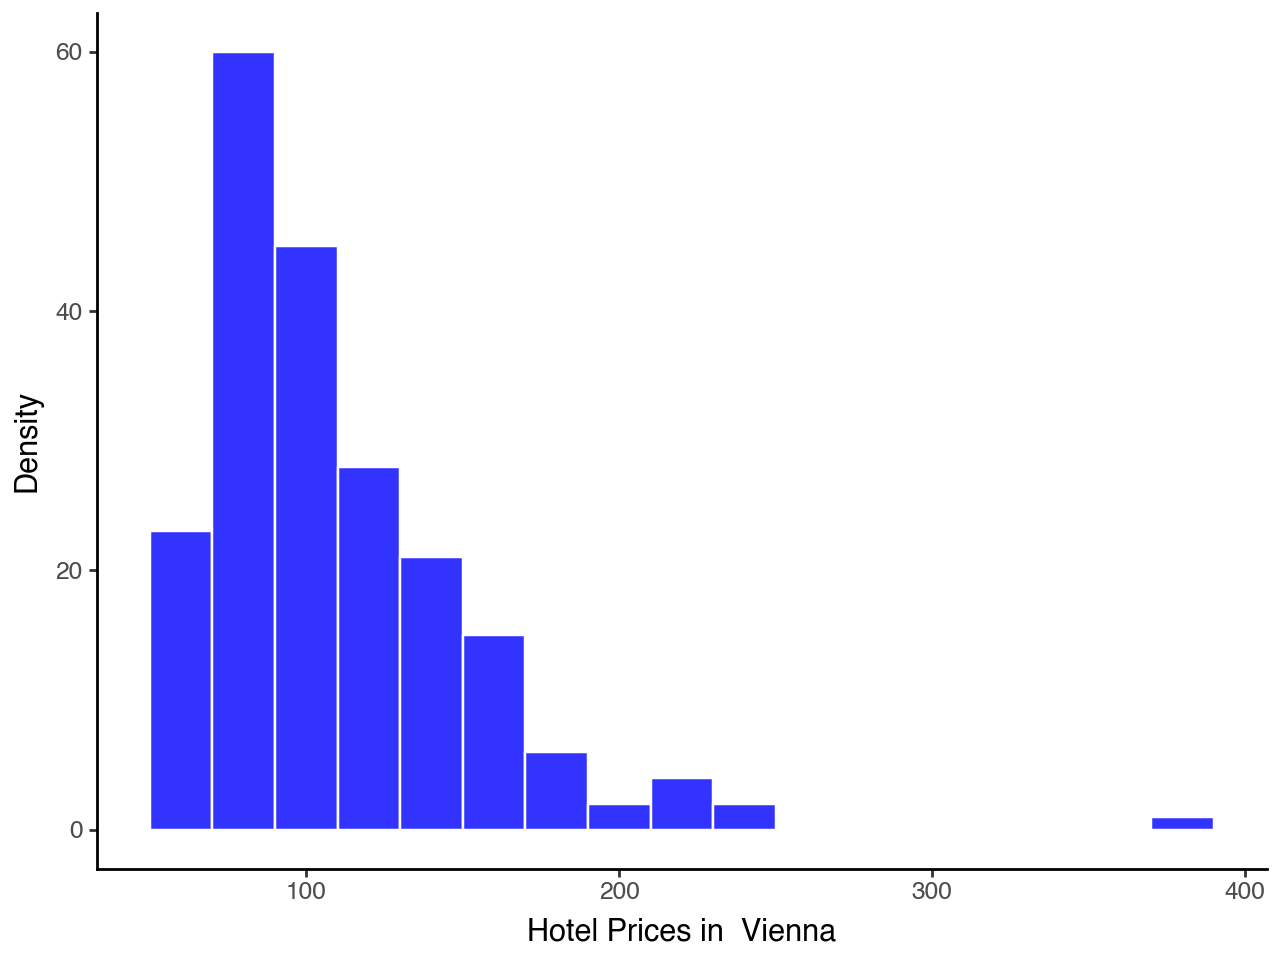

In [20]:
(
    ggplot(vienna_hotels, aes(x="price"))
    + geom_histogram(alpha=0.8, binwidth=20, color="white", fill="blue")
    + labs(x="Hotel Prices in  Vienna", y="Density")
    + theme_classic()
)

theme_minimal

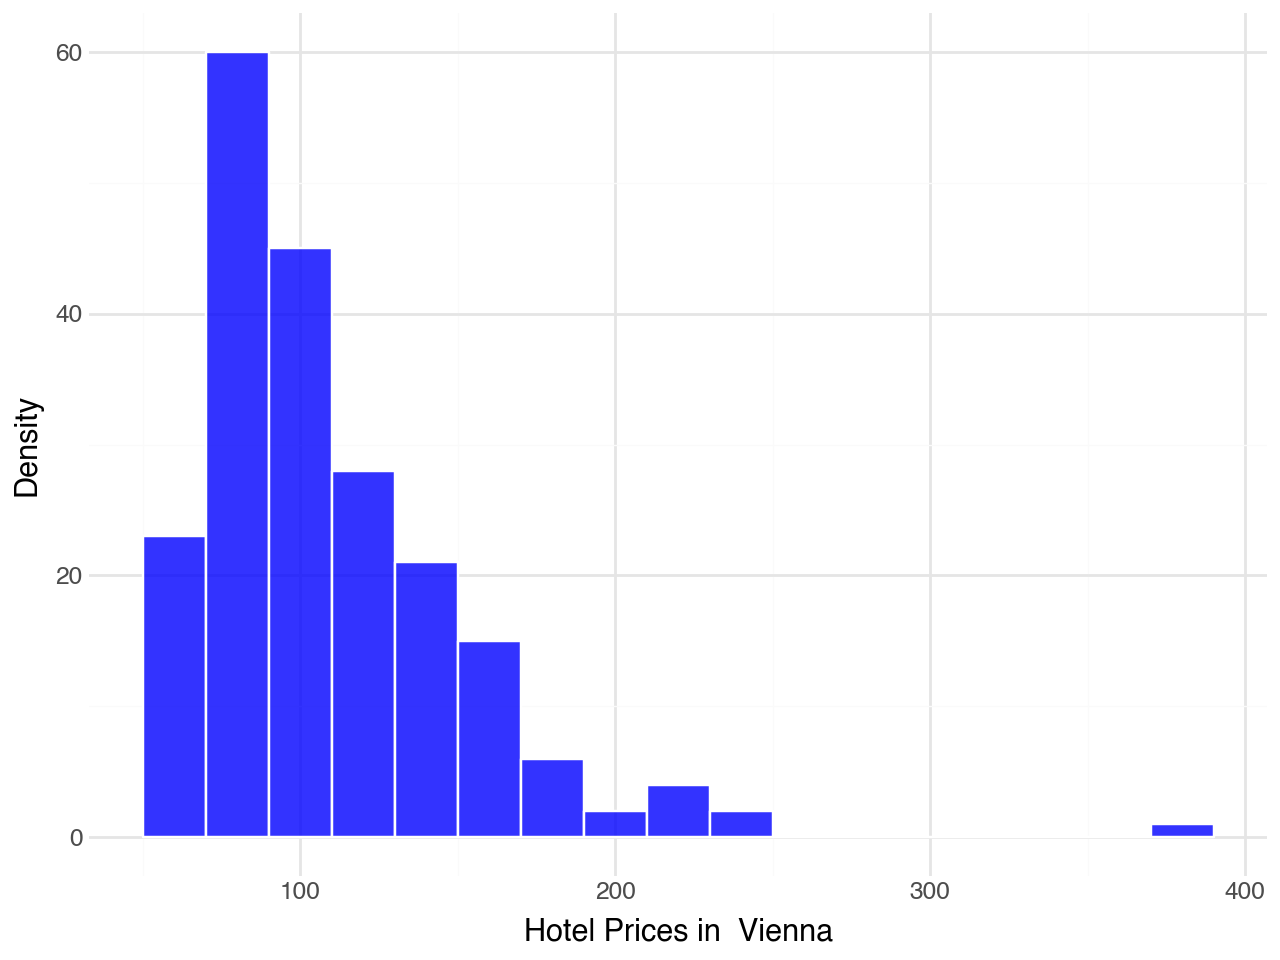

In [21]:
(
    ggplot(vienna_hotels, aes(x="price"))
    + geom_histogram(alpha=0.8, binwidth=20, color="white", fill="blue")
    + labs(x="Hotel Prices in  Vienna", y="Density")
    + theme_minimal()
)

In the book, and in this class we usually use `theme_bw`

### Manipulating Axis

Create a plotnine object

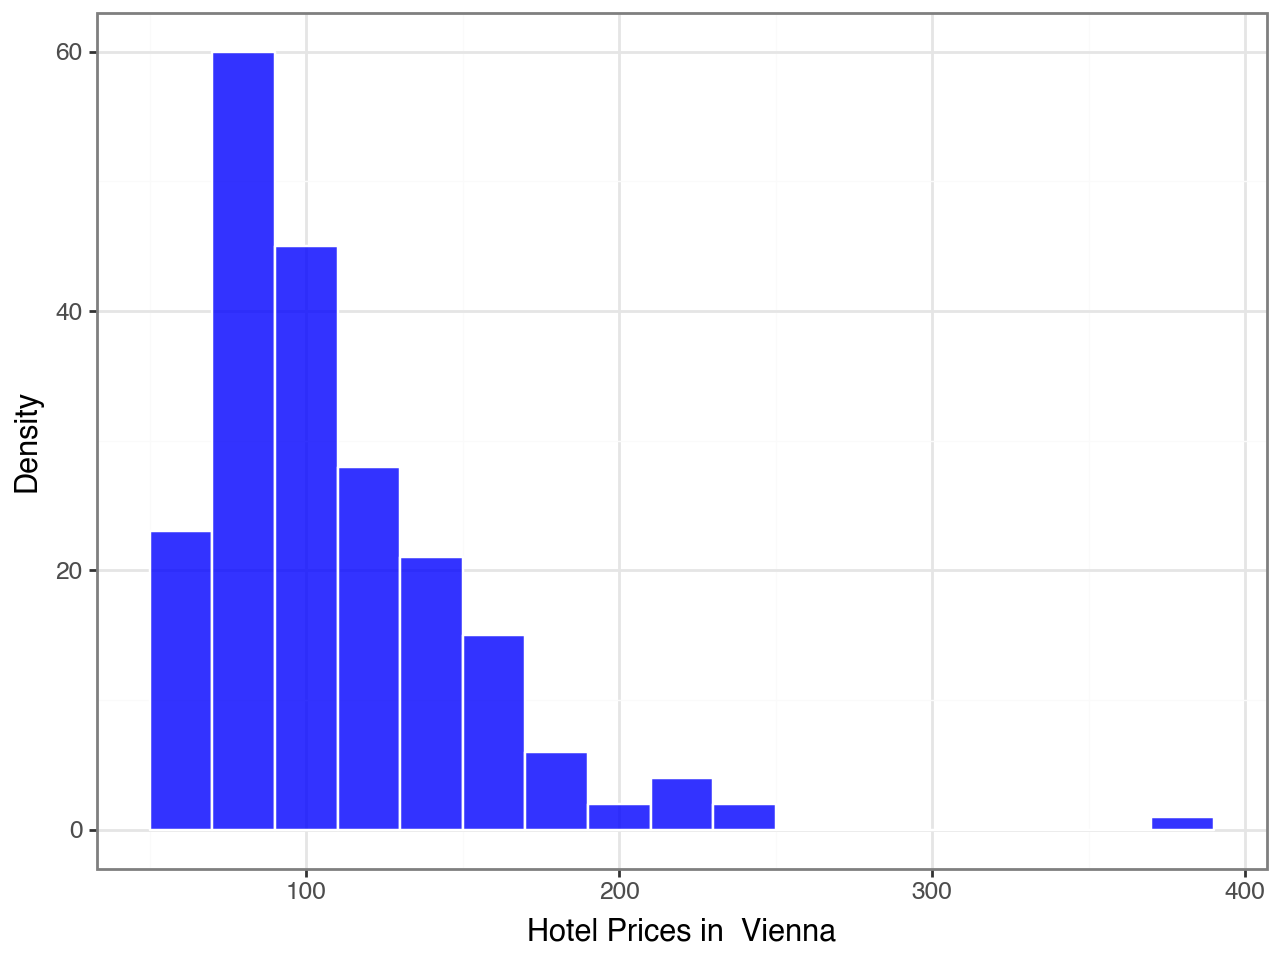

In [22]:
f1 = (
    ggplot(vienna_hotels, aes(x="price"))
    + geom_histogram(alpha=0.8, binwidth=20, color="white", fill="blue")
    + labs(x="Hotel Prices in  Vienna", y="Density")
    + theme_bw()
)
f1 

Set the axis: 

    1) if continuous variable: `scale_()_continuous`
    2) if discrete/categorical variable: `scale_()_discrete`

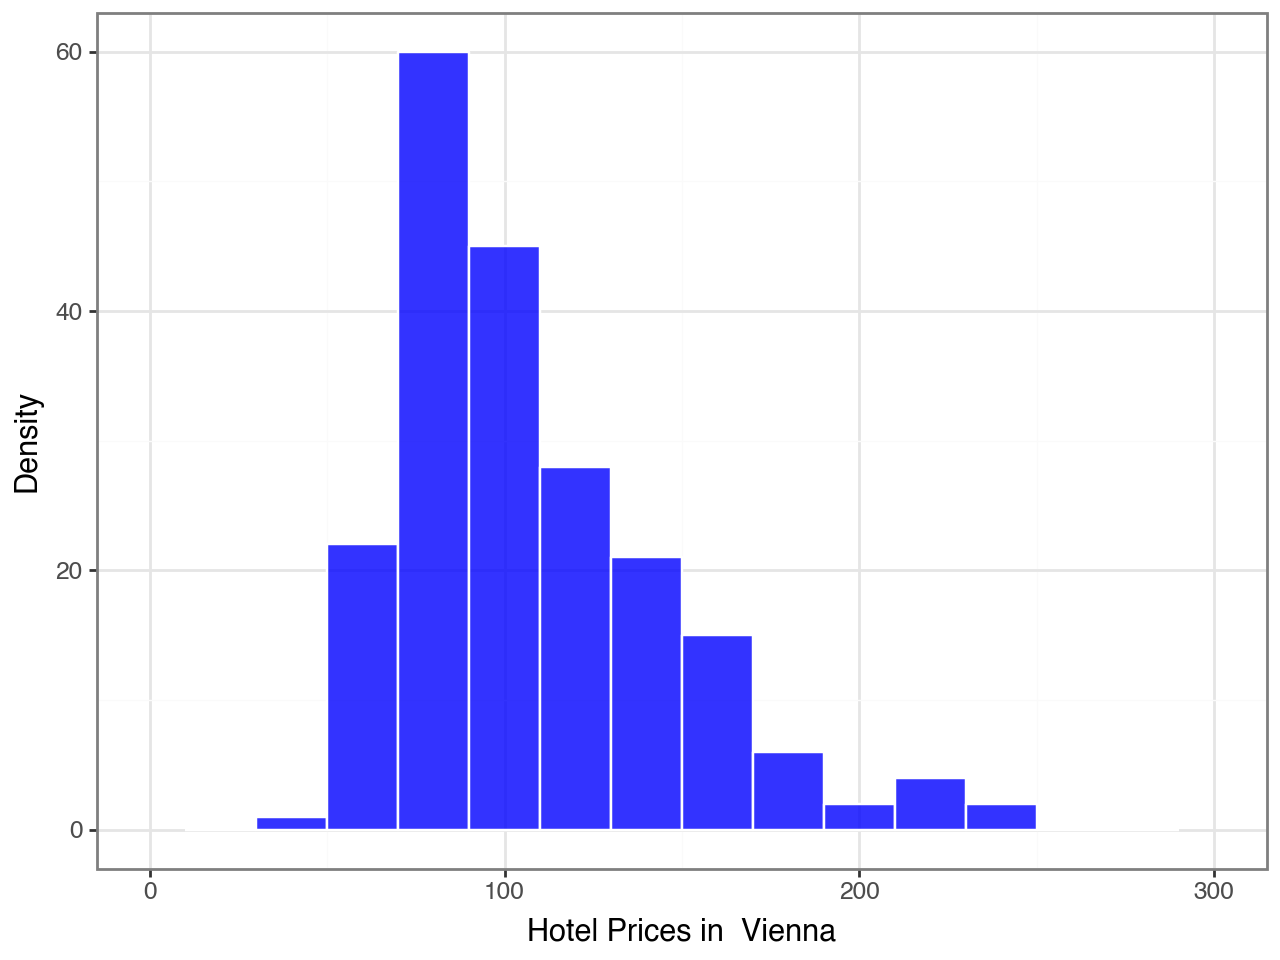

In [23]:
# a) limit -> changes the limit
f1 + scale_x_continuous(limits=(0, 300))

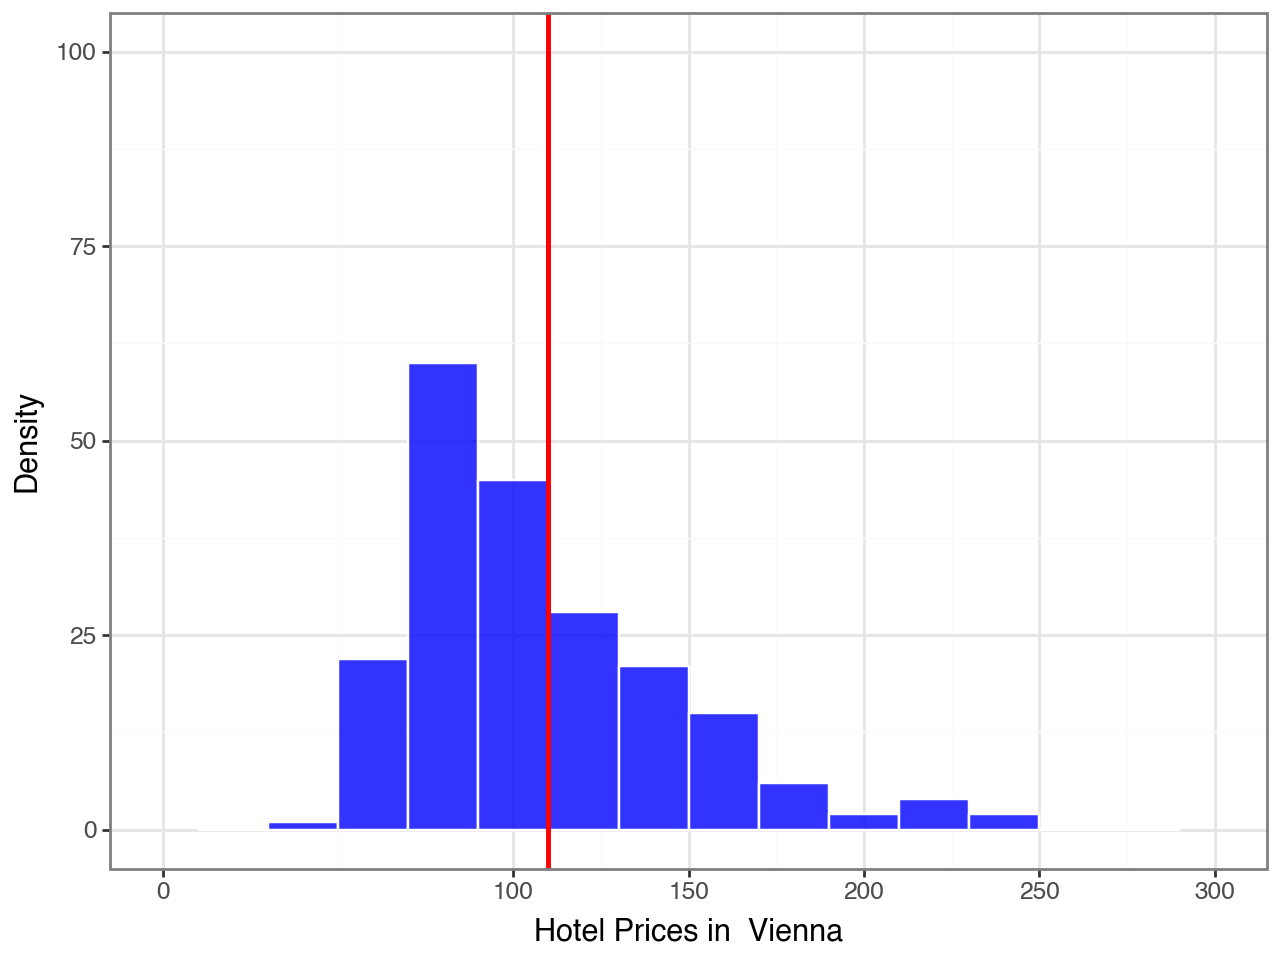

In [38]:
# b) set tickers, called 'breaks'
f1 + scale_x_continuous(limits=(0, 300), breaks=(0, 100, 150, 200, 250, 300))

#### Task: - use only one graph!

  1) Set limits between 0  and 500 for x axis\
  2) Set the breaks with binwidth of 50 for X. Use `np.arange` function instead of typing in each of them!\
  3) set the limits for Y between 0 and 100\
  4) Set the breaks with binwidth of 10 for Y

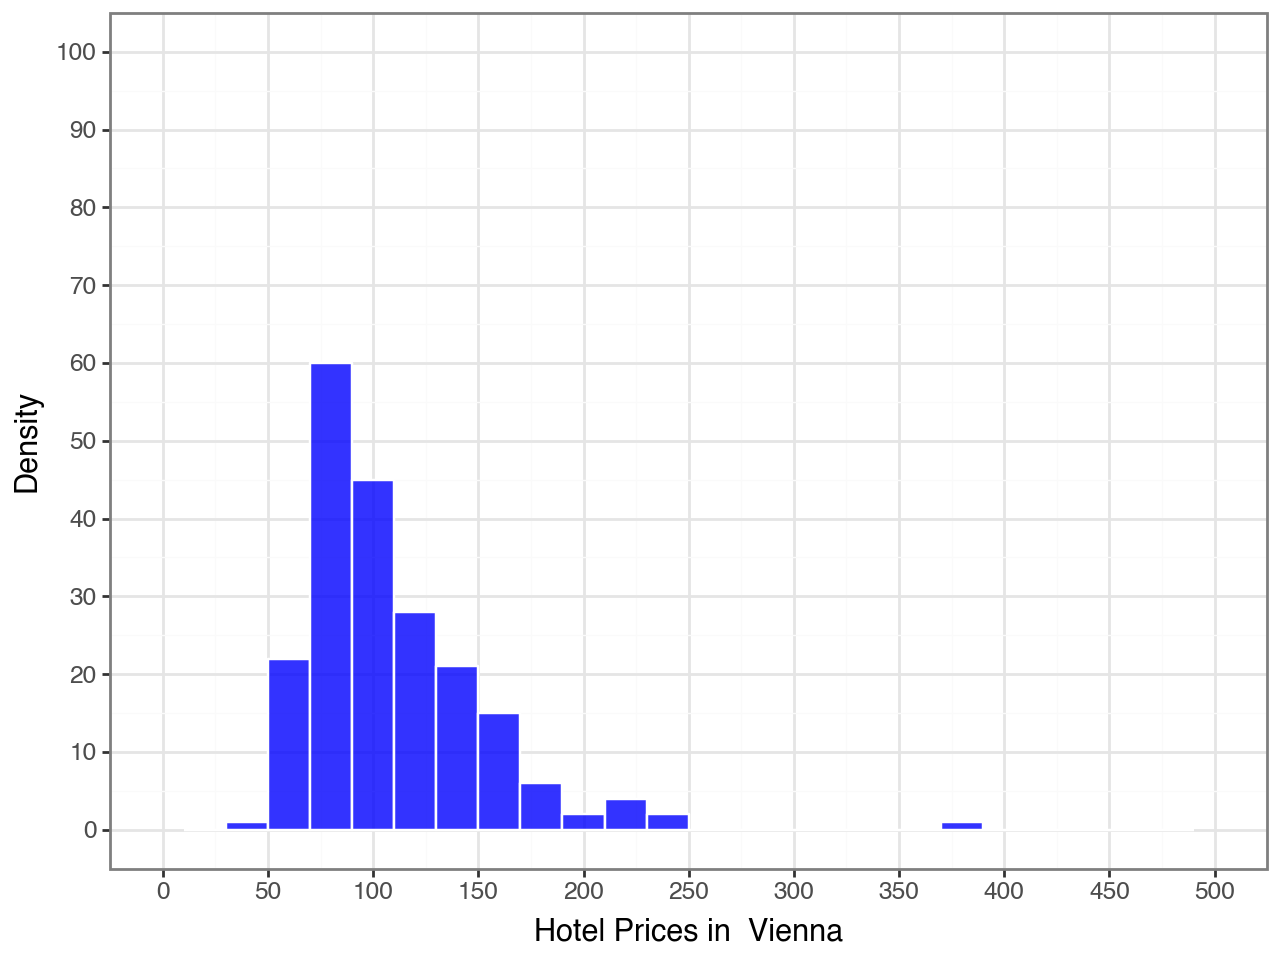

In [25]:
(
    f1
    + scale_x_continuous(limits=(0, 500), breaks=np.arange(0, 501, 50))
    + scale_y_continuous(limits=(0, 100), breaks=np.arange(0, 101, 10))
)

Note: `np.arrange` returns evenly spaced values within a given interval.

`np.arange` can be called with a varying number of positional arguments:

- `np.arange(stop)` : Values are generated within the half-open interval `[0, stop)` (in other words, the interval including start but excluding stop).

- `np.arange(start, stop)` : Values are generated within the half-open interval `[start, stop)`.

- `np.arange(start, stop, step)` :  Values are generated within the half-open interval `[start, stop)`, with spacing between values given by step.

For integer arguments the function is roughly equivalent to the Python built-in range, but returns an ndarray rather than a range instance.

### Adding lines, texts, ect. to your graph:

a) Add mean and median as lines and annotate them!

add a line as the mean:

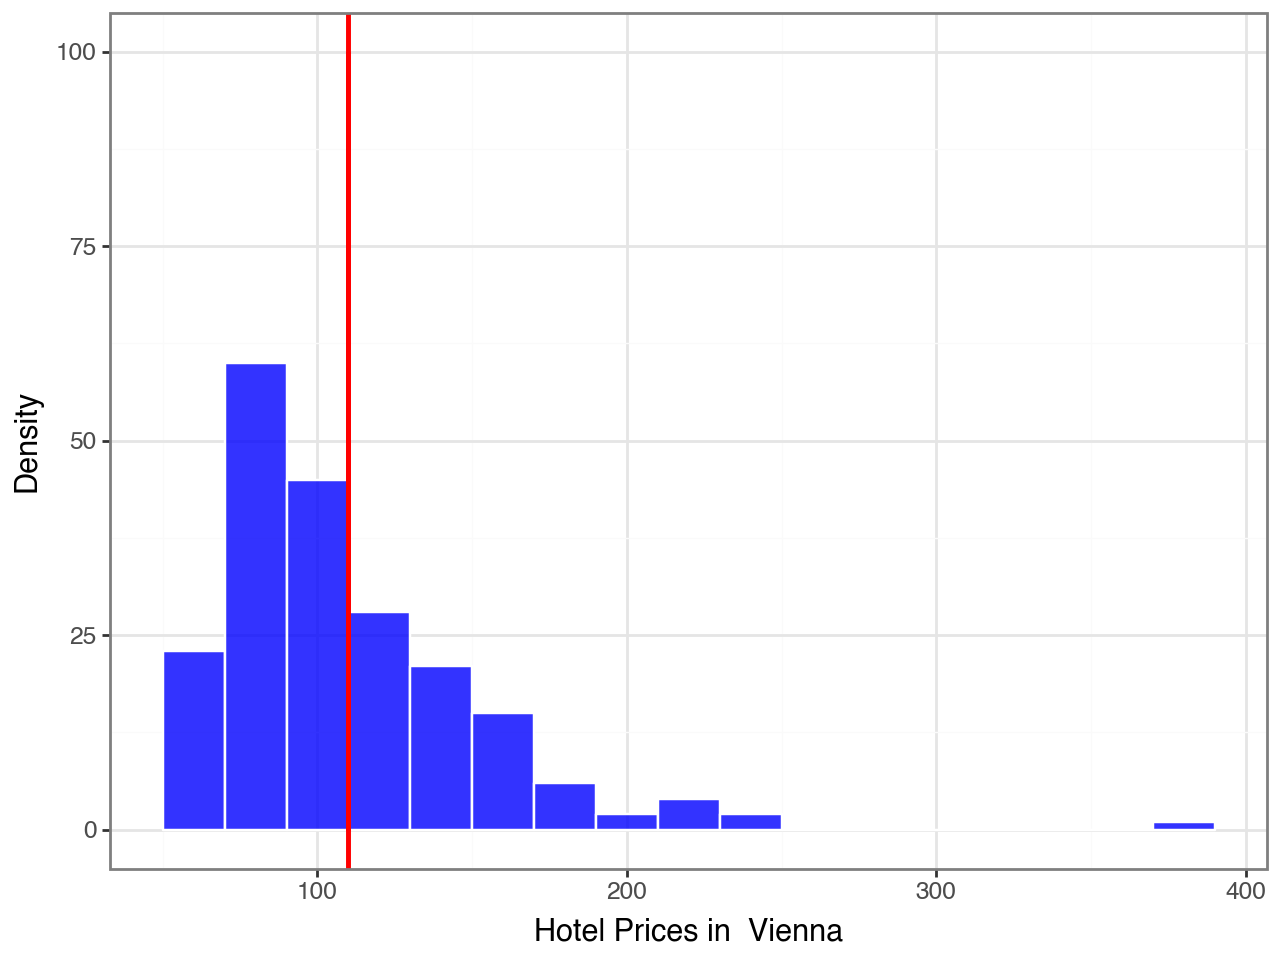

In [37]:
f1 = f1 + geom_segment( # Adds a vertical line to the plot 'f1' representing the mean price of hotels.
    aes( # Maps data variables to aesthetic attributes for the segment.
        x=vienna_hotels["price"].mean(), # X-coordinate for the start of the segment (mean price).
        y=0, # Y-coordinate for the start of the segment.
        xend=vienna_hotels["price"].mean(), # X-coordinate for the end of the segment (mean price).
        yend=60, # Y-coordinate for the end of the segment.
    ),
    color="red", # Sets the color of the segment to red.
    size=1, # Sets the size (thickness) of the segment to 1.)
)
f1


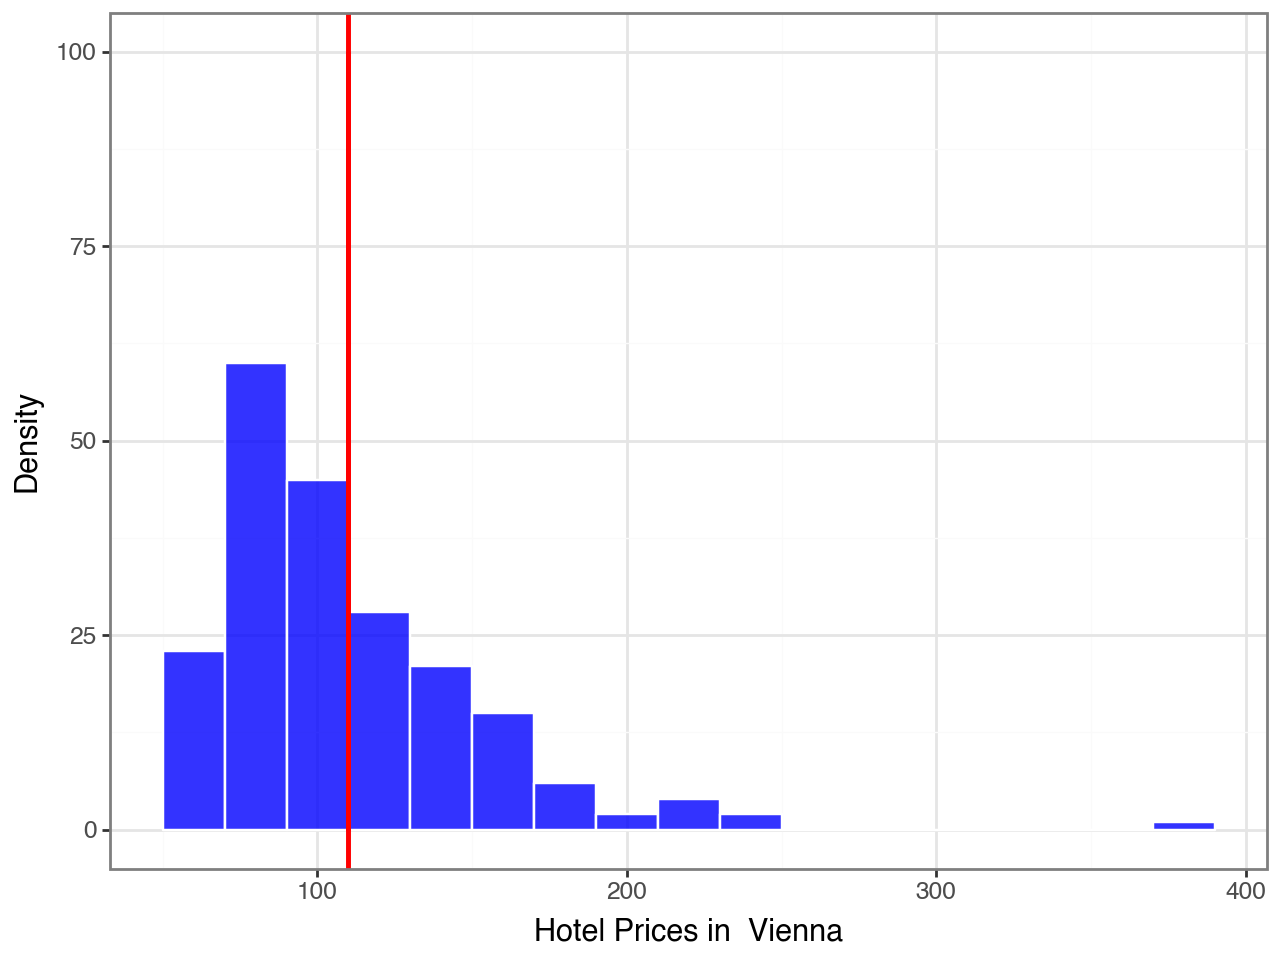

In [ ]:
f1_v = f1 + geom_vline(
    xintercept=vienna_hotels["price"].mean(),
    color="red",
    size=1
)
f1_v

add annotation which says it is the mean

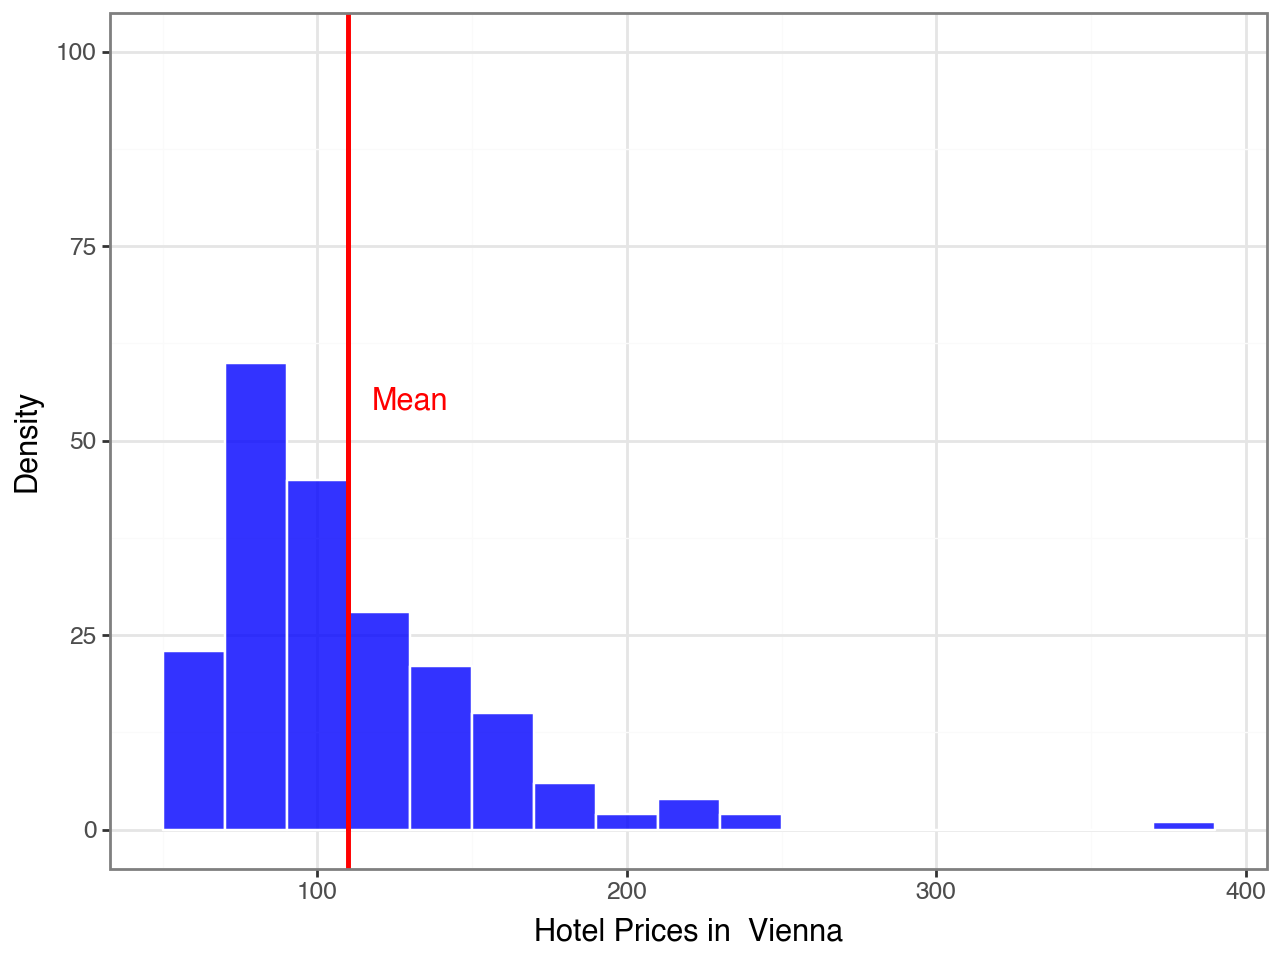

In [39]:
f1 = f1 + annotate(
    "text", x=vienna_hotels["price"].mean() + 20, y=55, label="Mean", color="red"
)
f1

Add the median as a vertical line to the graph

In [40]:
median_price = vienna_hotels["price"].median()

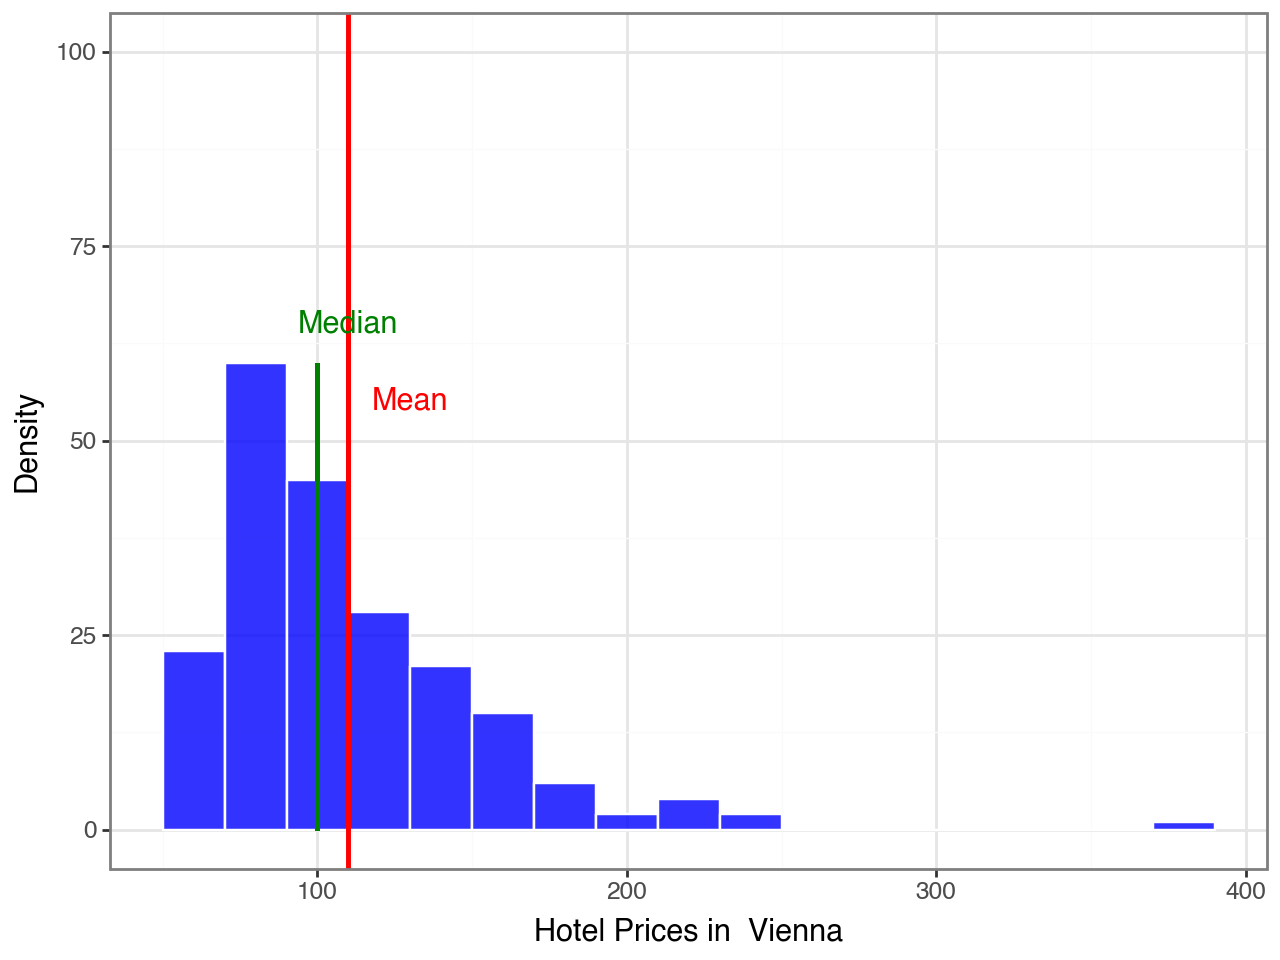

In [41]:
f1 = (
    f1
    + annotate("text", x=median_price + 10, y=65, label="Median", color="green")
    + geom_segment(
        aes(x=median_price, y=0, xend=median_price, yend=60), color="green", size=1
    )
)
f1

#### Task: 

add the 95th percentile to the figure

    advice: create a new variable f2 when trying to write this code
    here we have redefined the variable f1, however when developing a code
    it has several drawbacks to redefine a variable! Discuss!

In [42]:
pctg95_price = vienna_hotels["price"].quantile(q=0.95)

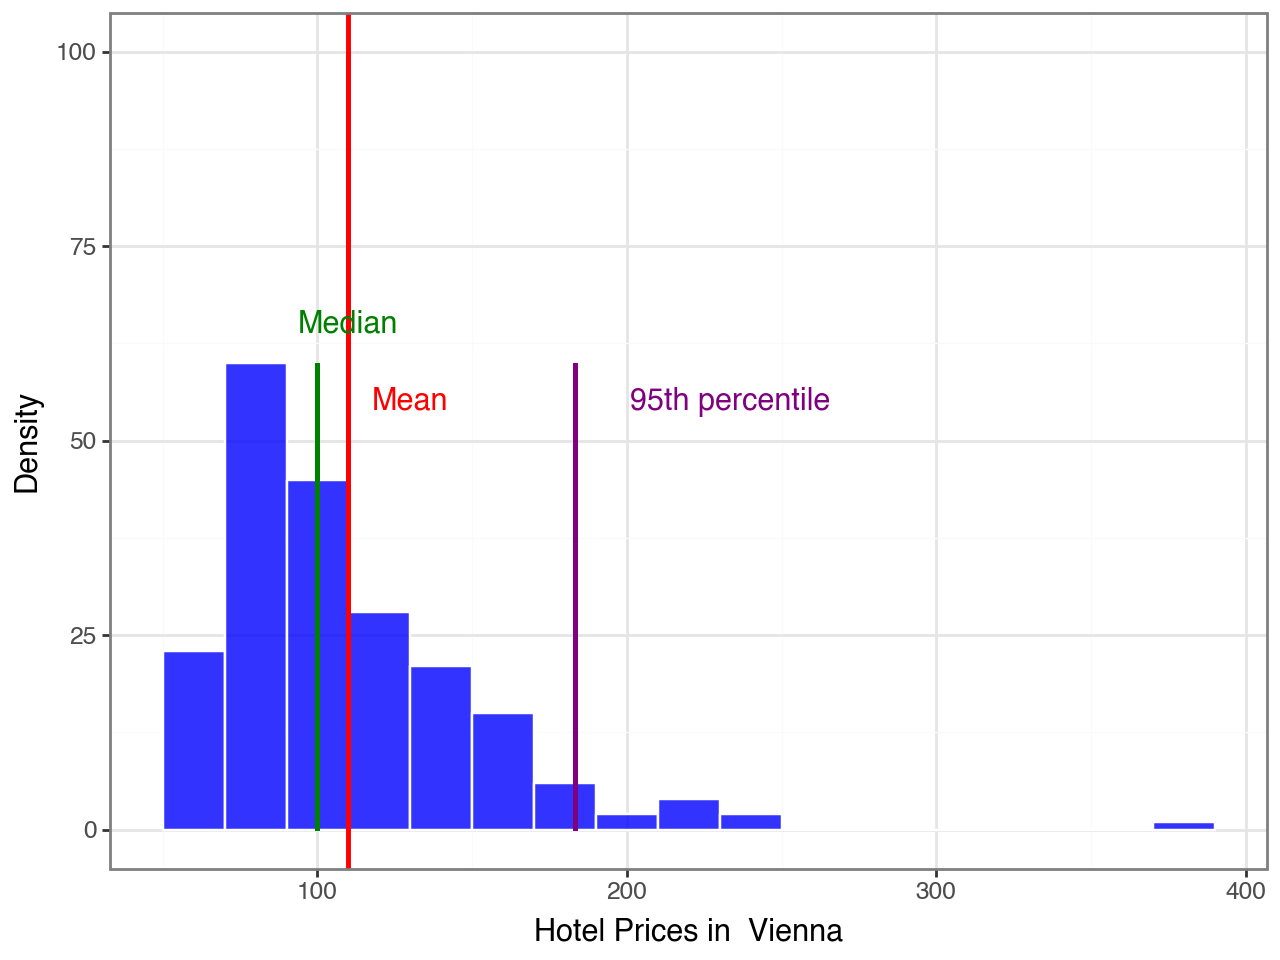

In [43]:
f2 = (
    f1
    + annotate(
        "text", x=pctg95_price + 50, y=55, label="95th percentile", color="purple"
    )
    + geom_segment(
        aes(x=pctg95_price, y=0, xend=pctg95_price, yend=60), color="purple", size=1
    )
)
f2

### Other frequently used plots

#### a. bar graph

 Summarize hotels which are close/medium or far away from the city-center:

Let create a new factor variable

In [ ]:
# Create a new categorical column 'distance_f' by binning the 'distance' column.
# - The 'distance' values are divided into three bins defined by the edges:
#   - (-1, 2]: labeled "close"
#   - (2, 4]: labeled "medium"
#   - (4, 100]: labeled "far"
# This converts a continuous numerical variable into an ordered categorical one.
df["distance_f"] = pd.cut(df["distance"], [-1, 2, 4, 100], labels=["close", "medium", "far"])
# pd.cut is used to segment and sort data values into bins.
# - The first argument `df["distance"]` is the series to be binned.
# - The second argument `[-1, 2, 4, 100]` defines the bin edges. For example, the first bin includes values greater than -1 and less than or equal to 2.
# - The `labels=["close", "medium", "far"]` argument assigns a name to each bin.
# This operation is useful for converting continuous numerical data into discrete categories.


We are curious about how these hotels distribute in the cities\
Summarize the number of close/medium/far hotels


In [45]:
ds0 = df.groupby(["city","distance_f"])["hotel_id"].count().rename("N").reset_index()
ds0

,city,distance_f,N
0,London,close,187
1,London,medium,172
2,London,far,76
3,Vienna,close,161
4,Vienna,medium,38
5,Vienna,far,8


Do the plot:

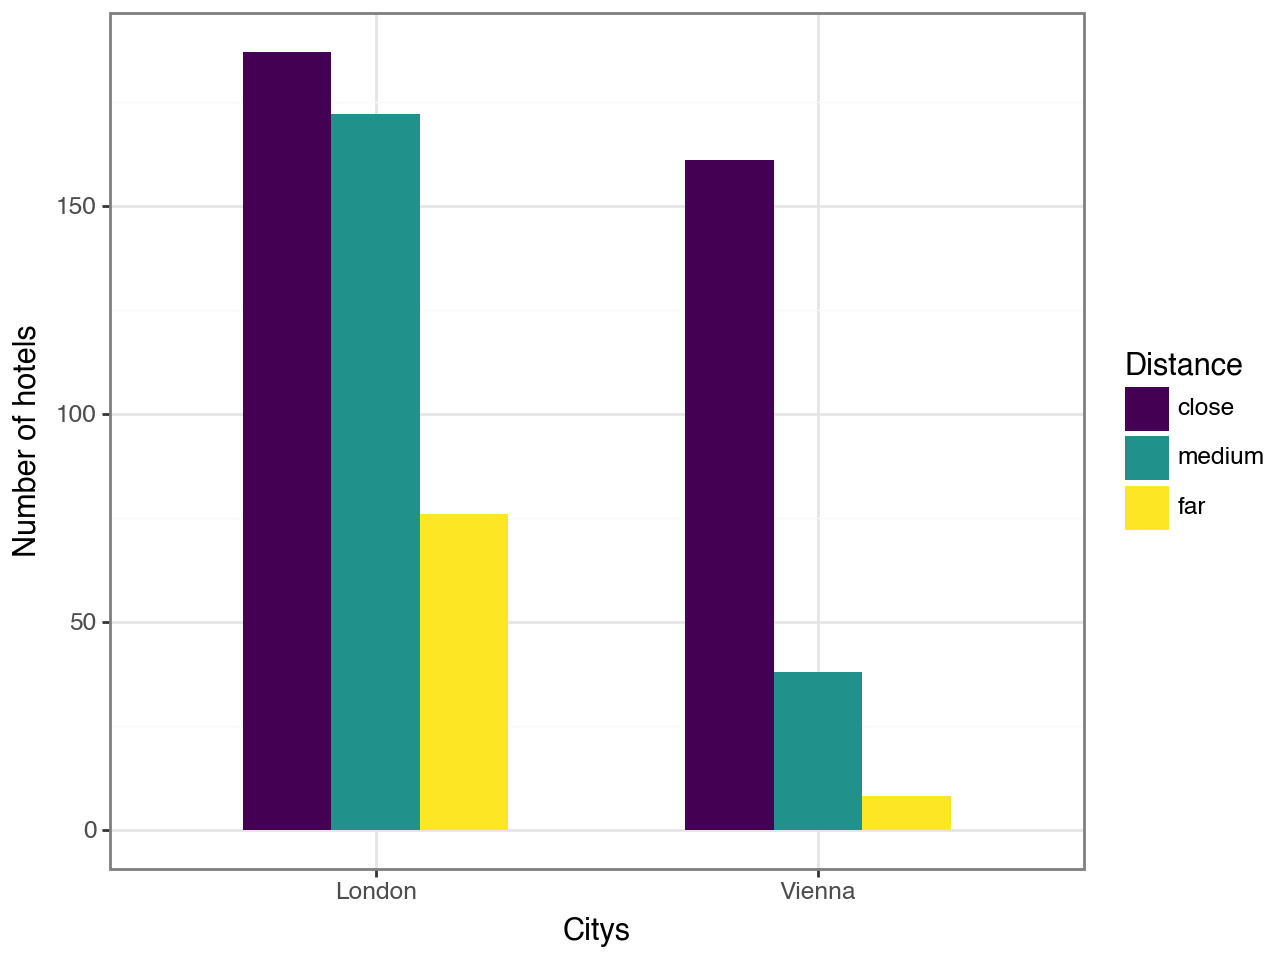

In [46]:
f3 = (
    ggplot(ds0, aes(x="city", y="N", fill="distance_f"))
    + geom_bar(stat="identity", position="dodge", width=0.6, size=0.5)
    + labs(x="Citys", y="Number of hotels", fill="Distance")
    + theme_bw()
)
f3

Make the legends more pretty: put to the top

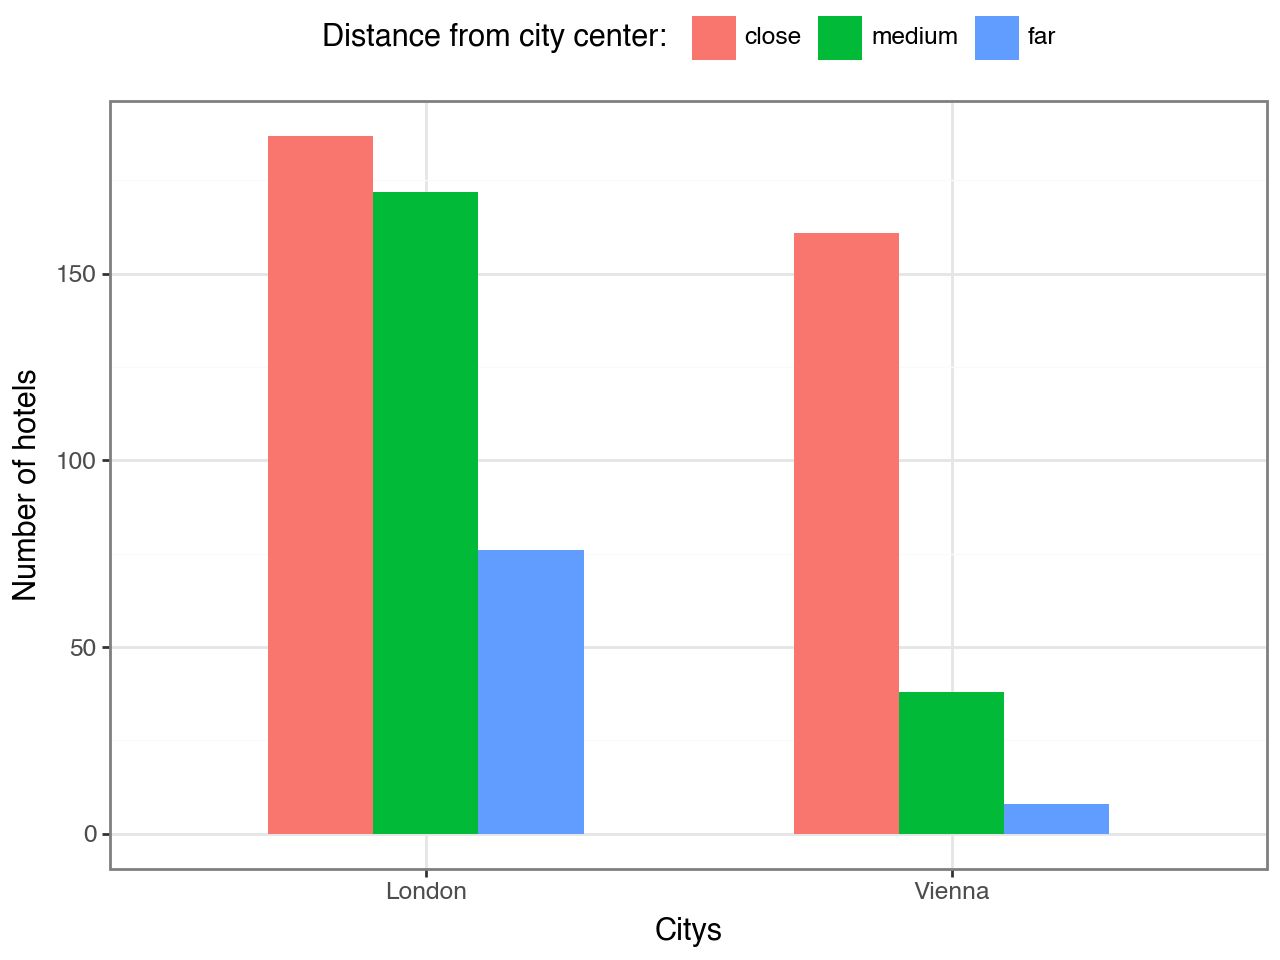

In [47]:
f3 = (
    f3
    + scale_fill_discrete(name="Distance from city center:")
    + theme(legend_position="top")
)
f3

For stacked bar, within the `geom_bar` function, set the `position` parameter to `stack`

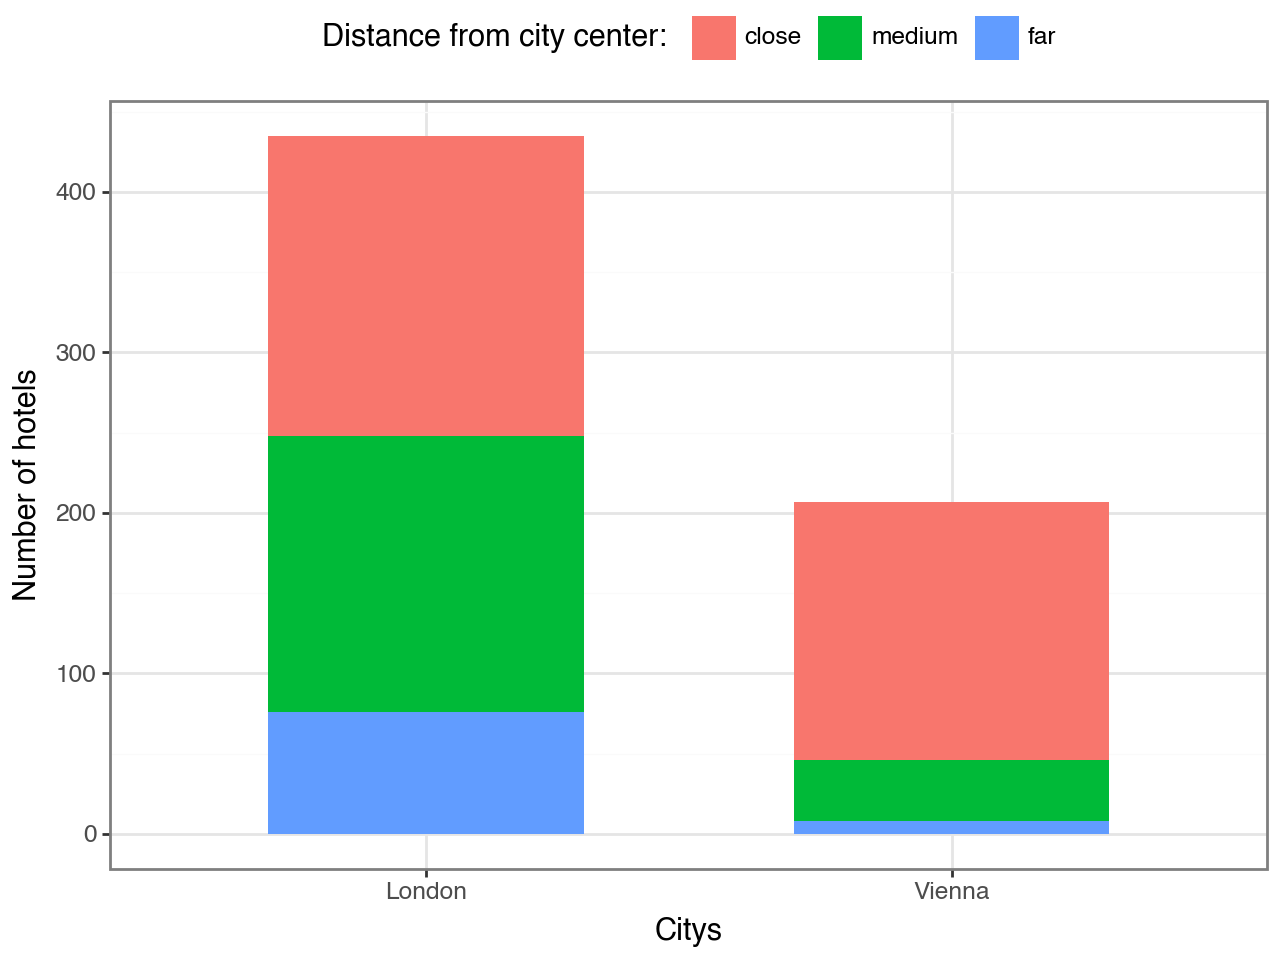

In [48]:
(
    ggplot(ds0, aes(x="city", y="N", fill="distance_f"))
    + geom_bar(stat="identity", position="stack", width=0.6, size=0.5)
    + labs(x="Citys", y="Number of hotels", fill="Distance")
    + scale_fill_discrete(name="Distance from city center:")
    + theme_bw()
    + theme(legend_position="top")
)

Stacked bar with percentages: using `mizani` package

In [49]:
from mizani.formatters import percent_format

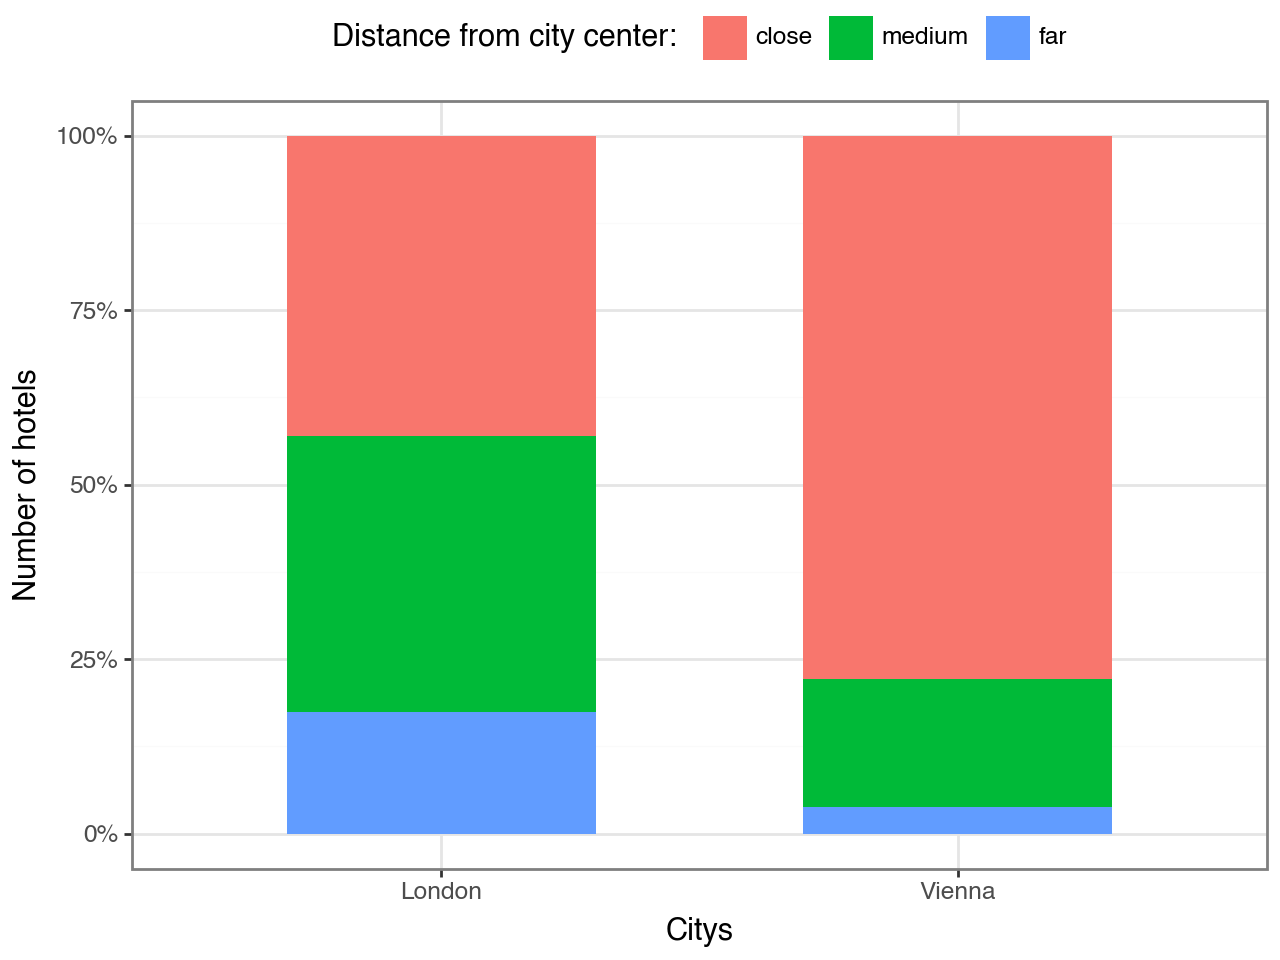

In [50]:
(
    ggplot(ds0, aes(x="city", y="N", fill="distance_f"))
    + geom_bar(stat="identity", position="fill", width=0.6, size=0.5)
    + labs(x="Citys", y="Number of hotels", fill="Distance")
    + scale_y_continuous(labels=percent_format())
    + scale_fill_discrete(name="Distance from city center:")
    + theme_bw()
    + theme(legend_position="top")
)

#### b. Box-plot: great for describe the distribution of the variable in a compact way:
   
Remember: extreme values, lower/upper adjacent = 1.5*IQR, IQR(25%,75%) and median (NO MEAN!)


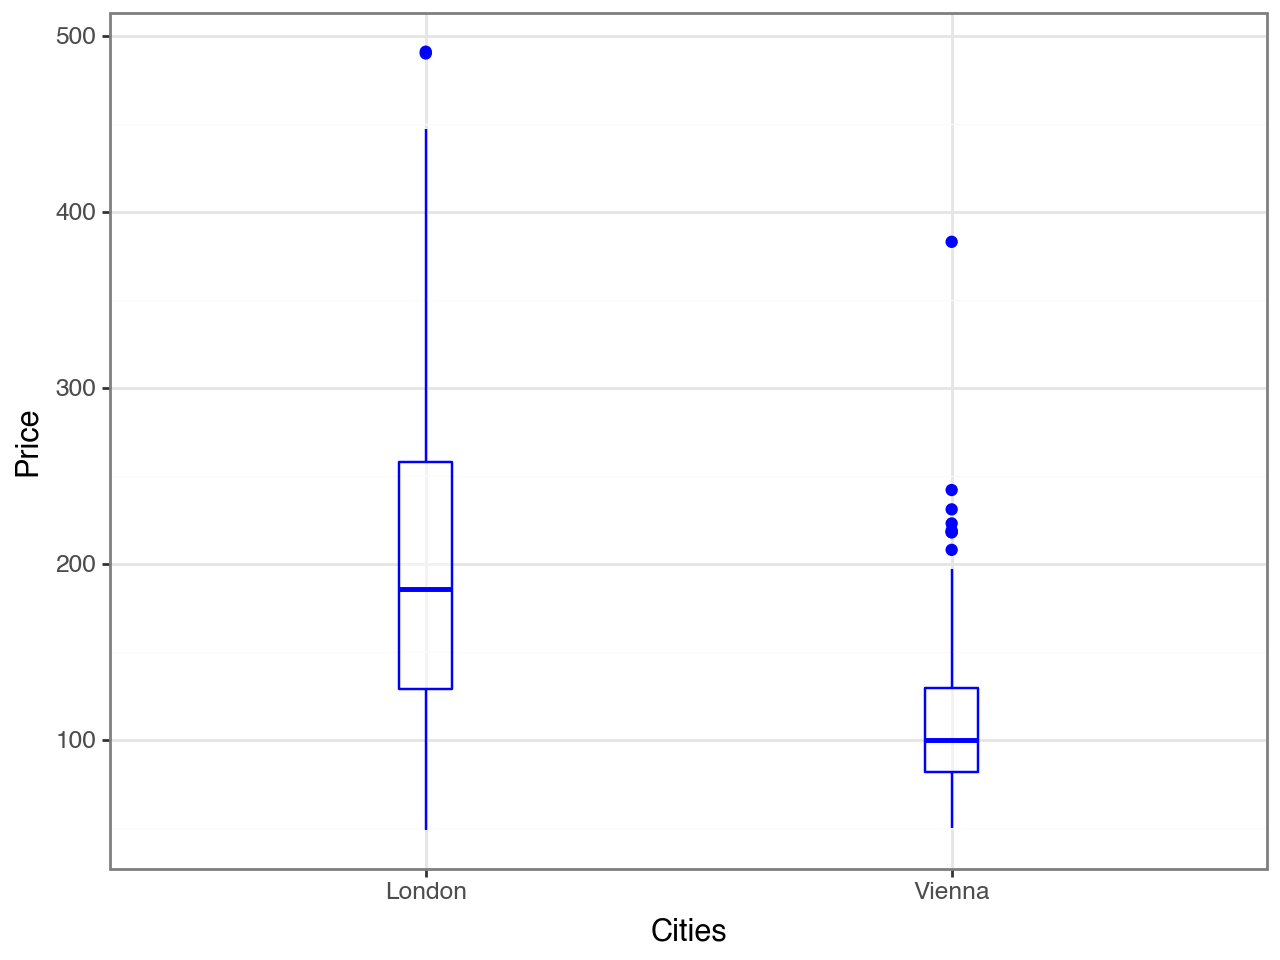

In [51]:
f4 = (
    ggplot(df, aes(y="price", x="city"))
    + geom_boxplot(color="blue", size=0.5, width=0.1, alpha=0.5)
    + labs(x="Cities", y="Price")
    + theme_bw()
)
f4

Make it a bit more fancy by adding error-bars


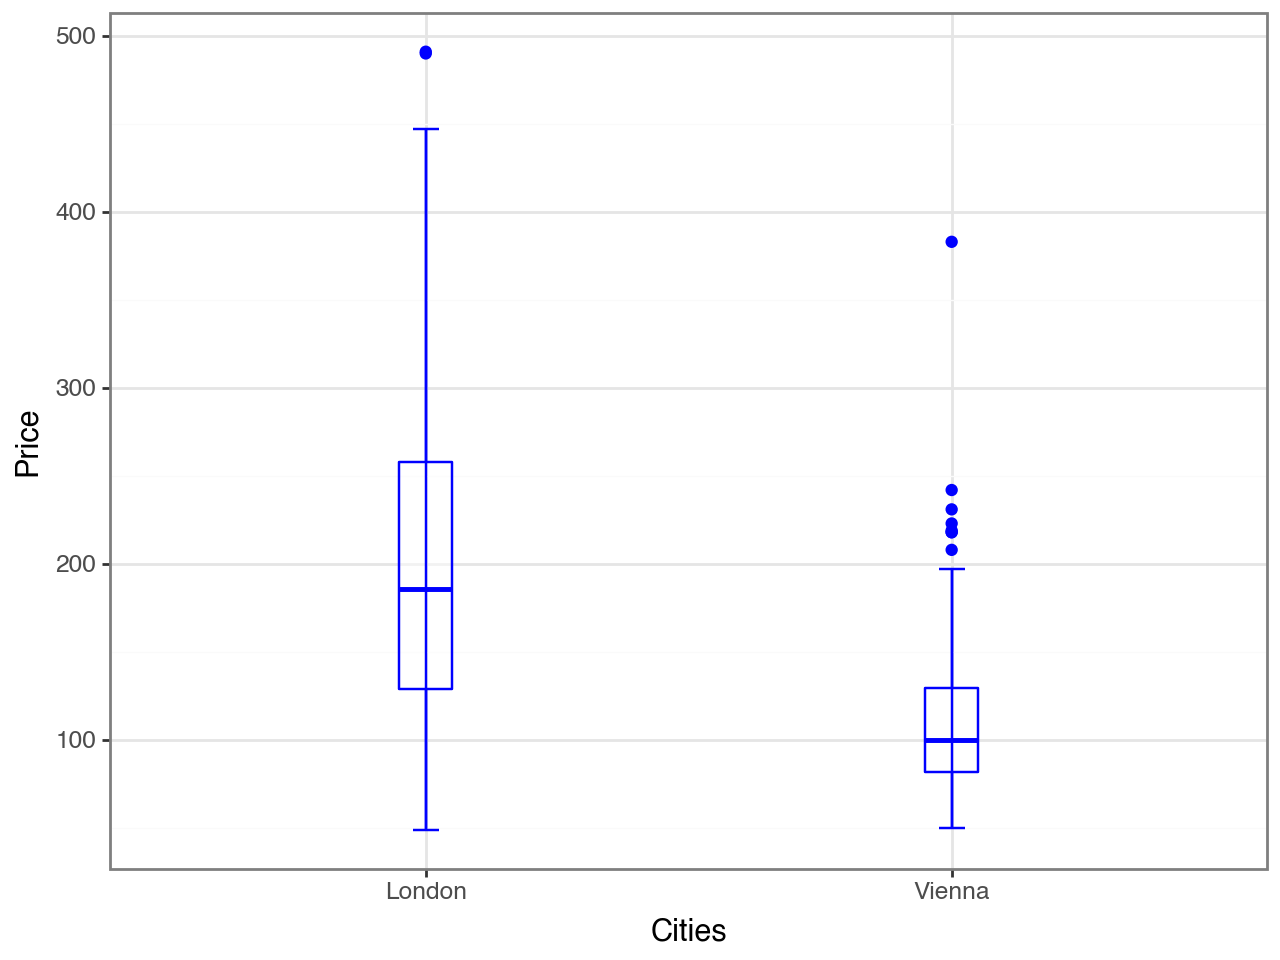

In [52]:
f4 = f4 + stat_boxplot(geom = "errorbar", width = 0.05,  size = 0.5, color = 'blue')
f4


Add the mean as a dot

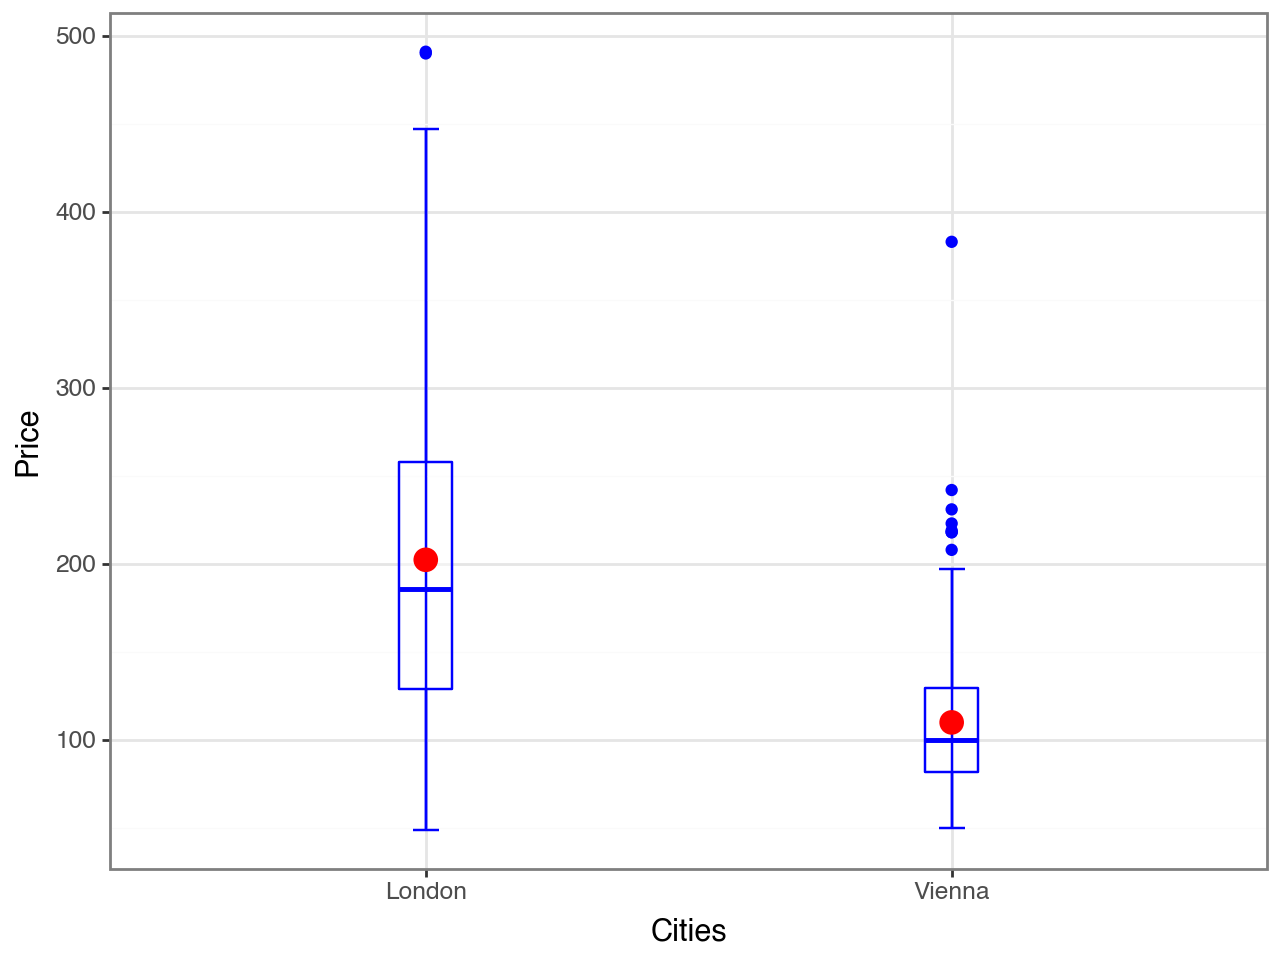

In [53]:
f4 + stat_summary(fun_data="mean_se", geom="point", size=4, color="red", fill="red")

#### c. Violin plot (+boxplot)

violin plots adds a kernel density estimator to the boxplot in a neat way


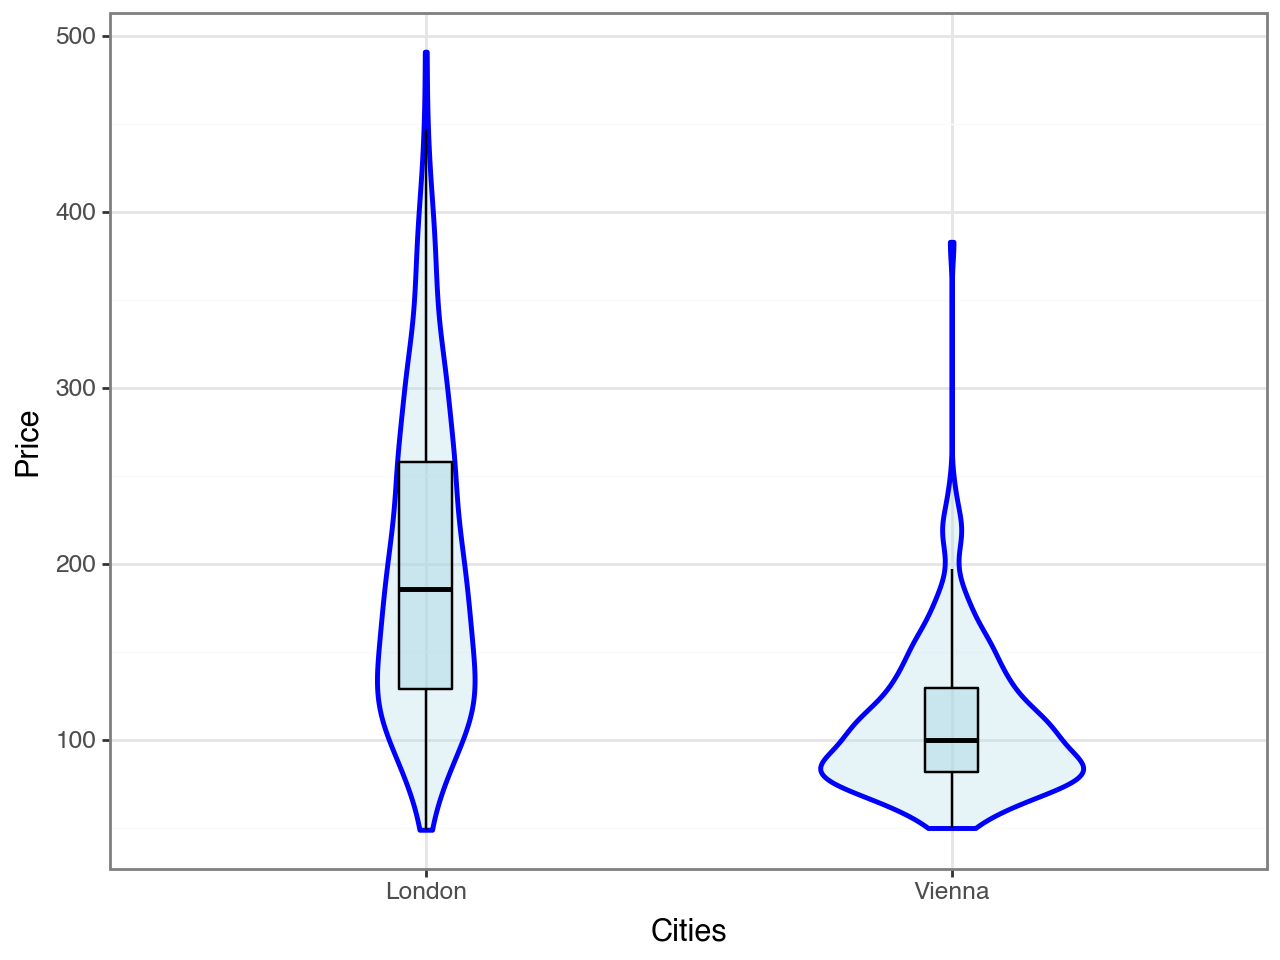

In [54]:
(
    ggplot(df, aes(y="price", x="city"))
    + geom_violin(
        size=1,
        width=0.5,
        color="blue",
        fill="lightblue",
        trim=True,
        show_legend=False,
        alpha=0.3,
    )
    + geom_boxplot(
        color="black", fill="lightblue", size=0.5, width=0.1, alpha=0.5, outlier_alpha=0
    )
    + labs(x="Cities", y="Price")
    + theme_bw()
)

Extra: can be an extra homework or good for demonstration of a conditional box-plot graph.

#### Task:

  1) Create a conditional box-plot for hotel prices, conditioning on the city
  
  2) Add error bars to box-plot
  
  3) Add conditional mean as dots
  
  4) Annotate everything with arrows:
      `geom_segment(aes(x=,y=,xend=,yend=),arrow=arrow(),color=)`
      
  5) use theme_bw()
  
  6) Instead of using 'color = 'blue'', or other colors, use 'color = color[0]' or color[x]

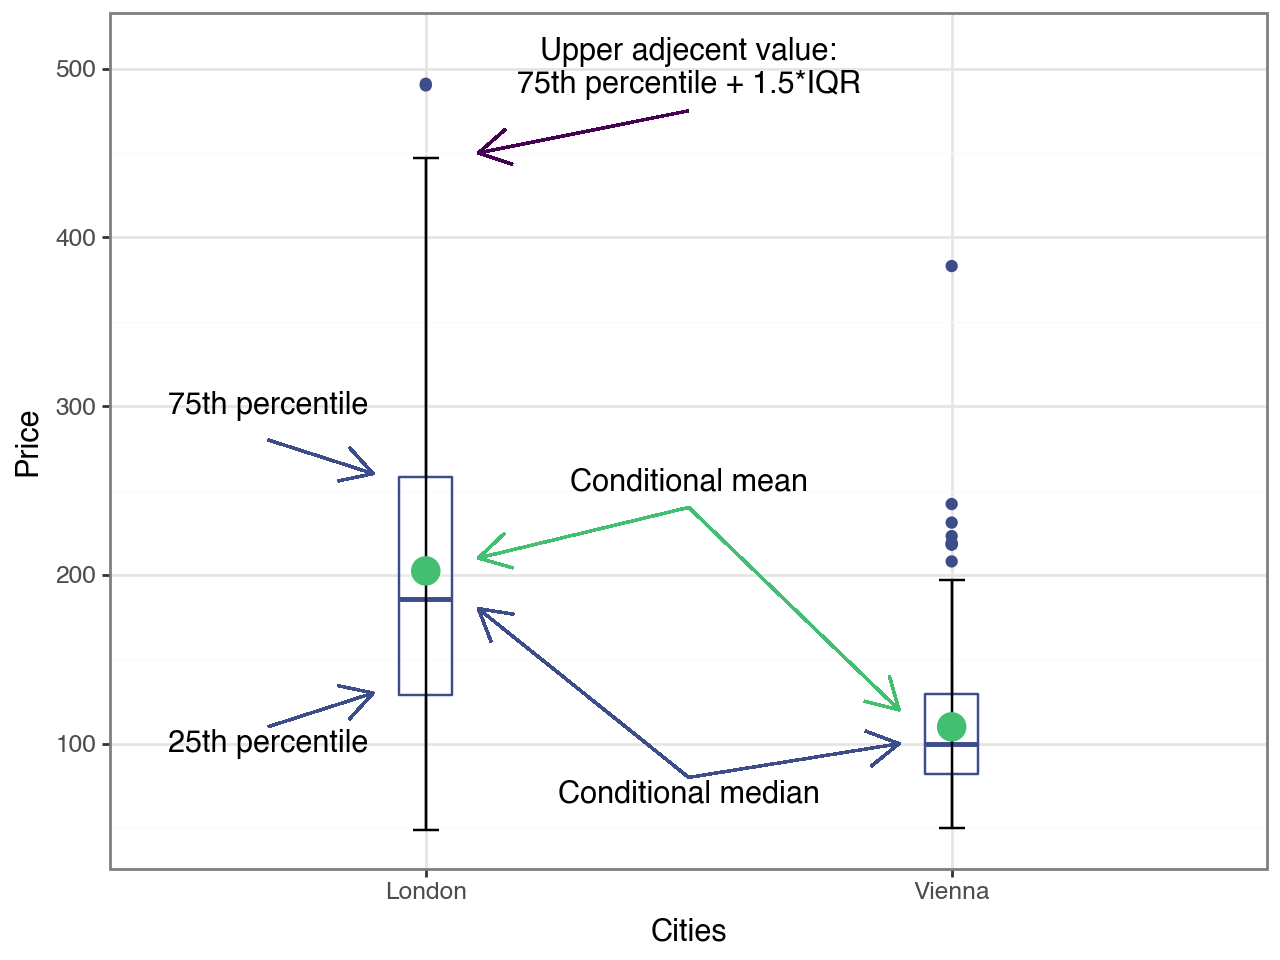

In [55]:
color = ["#3D4D8AFF", "#43BF71FF", "#440154FF", "#FDE725FF", "#23888EFF"] # these are the colors used in the book

(
    ggplot(df, aes(y="price", x="city"))
    + geom_boxplot(color=color[0], size=0.5, width=0.1, alpha=0.3, outlier_alpha=0.3)
    + labs(x="Cities", y="Price")
    + stat_boxplot(geom="errorbar", width=0.05, size=0.5)
    + stat_summary(
        fun_data="mean_se", geom="point", size=5, color=color[1], fill=color[1]
    )
    + annotate("text", x=1.5, y=255, label="Conditional mean")
    + geom_segment(aes(x=1.5, y=240, xend=1.1, yend=210), arrow=arrow(), color=color[1])
    + geom_segment(aes(x=1.5, y=240, xend=1.9, yend=120), arrow=arrow(), color=color[1])
    + annotate("text", x=1.5, y=70, label="Conditional median")
    + geom_segment(aes(x=1.5, y=80, xend=1.1, yend=180), arrow=arrow(), color=color[0])
    + geom_segment(aes(x=1.5, y=80, xend=1.9, yend=100), arrow=arrow(), color=color[0])
    + annotate("text", x=0.7, y=100, label="25th percentile")
    + geom_segment(aes(x=0.7, y=110, xend=0.9, yend=130), arrow=arrow(), color=color[0])
    + annotate("text", x=0.7, y=300, label="75th percentile")
    + geom_segment(aes(x=0.7, y=280, xend=0.9, yend=260), arrow=arrow(), color=color[0])
    + annotate("text", x=1.5, y=510, label="Upper adjecent value:")
    + annotate("text", x=1.5, y=490, label="75th percentile + 1.5*IQR")
    + geom_segment(aes(x=1.5, y=475, xend=1.1, yend=450), arrow=arrow(), color=color[2])
    + theme_bw()
)